# Pine Ridge Indian Reservation Bounding Box Map
Defines an approximate bounding box for the Pine Ridge Indian Reservation
Builds a simple spatial representation and plots the reservation area on a map using Python. 
Because reservation boundaries are complex and not perfectly rectangular, this uses a bounding box approximation 
derived from published coordinate extents (centered around ~43.0–43.4°N, -102.7 to -101.6°W based on geographic extent data.

In [1]:
# Install required packages (uncomment and run the following if needed)
# !pip install geopandas matplotlib shapely contextily

# Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from shapely.geometry import box

In [2]:
# Define crs
CRS_WGS84 = "EPSG:4326"   
CRS_WEB   = "EPSG:3857"   
CRS_USA   = "EPSG:5070"   

In [3]:
# Define bounding box for Pine Ridge Reservation
# Approximate extent based on published geographic coordinates

min_lon = -102.75   # west boundary (approx)
max_lon = -101.60   # east boundary (approx)
min_lat =  42.90    # south boundary (approx)
max_lat =  43.55    # north boundary (approx)

# Reminder!
''' Min_lon = west (longitude)
    MaxX_lon = east (longitude)
    Min_lat = south (latitude)
    Max_lat = north (latitude)'''

' Min_lon = west (longitude)\n    MaxX_lon = east (longitude)\n    Min_lat = south (latitude)\n    Max_lat = north (latitude)'

In [4]:
# Create polygon (bounding box)
bbox_polygon = Polygon([
    (min_lon, min_lat),
    (min_lon, max_lat),
    (max_lon, max_lat),
    (max_lon, min_lat),
    (min_lon, min_lat)
])

In [5]:
# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    index=["Pine Ridge Bounding Box"],
    geometry=[bbox_polygon],
    crs="EPSG:4326"
)

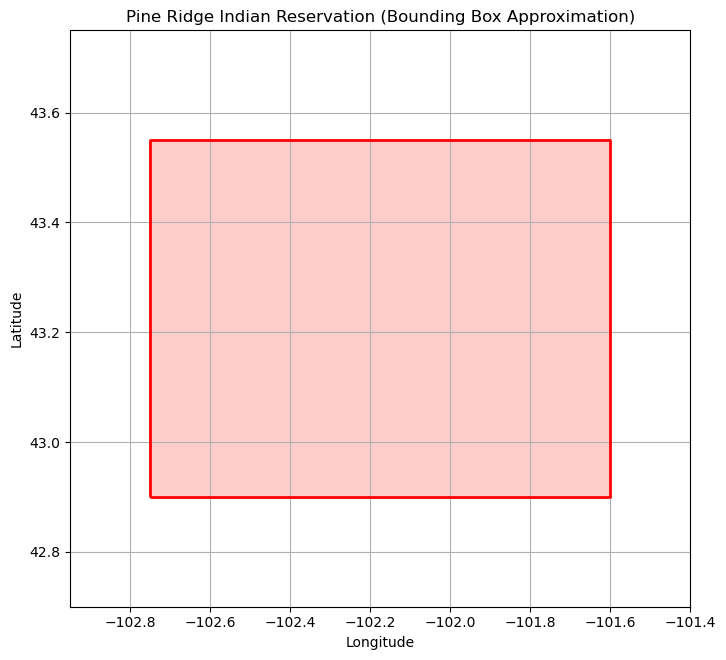

In [6]:
# Plot the bounding box

fig, ax = plt.subplots(figsize=(8, 8))

gdf.boundary.plot(ax=ax, linewidth=2, color="red")
gdf.plot(ax=ax, alpha=0.2, color="red")

# Add labels and styling
ax.set_title("Pine Ridge Indian Reservation (Bounding Box Approximation)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_xlim(min_lon - 0.2, max_lon + 0.2)
ax.set_ylim(min_lat - 0.2, max_lat + 0.2)

plt.grid(True)
plt.show()

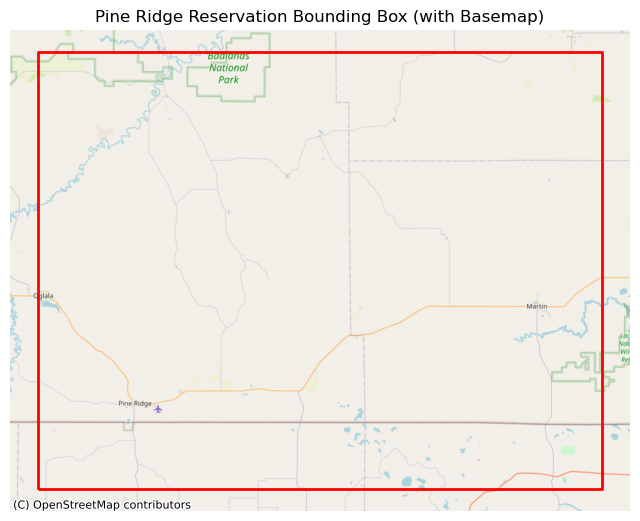

In [7]:
# Plot with a basemap using contextily
import contextily as cx

# Convert to Web Mercator for basemap compatibility
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))

gdf_web.boundary.plot(ax=ax, linewidth=2, color="red")

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title("Pine Ridge Reservation Bounding Box (with Basemap)")
ax.axis("off")

plt.show()

In [8]:
# Bounding box
minx, miny, maxx, maxy = -102.83934, 42.99758, -101.63487, 43.58962

reservation_bbox = box(minx, miny, maxx, maxy)

reservation_gdf = gpd.GeoDataFrame(
    {"name": ["Pine Ridge Reservation (BBox)"]},
    geometry=[reservation_bbox],
    crs=CRS_WGS84
)

In [9]:
# Towns and communities

town_data = [
    ("Martin", -101.741734, 43.167330, -101.720731, 43.179616),
    ("Batesland", -102.106009, 43.123842, -102.098151, 43.129328),
    ("Allen", -101.961190, 43.264171, -101.895143, 43.290470),
    ("Kyle", -102.194946, 43.411737, -102.163189, 43.438131),
    ("Manderson-White Horse Creek", -102.541440, 43.203819, -102.458387, 43.256516),
    ("Oglala", -102.800009, 43.144516, -102.680387, 43.209330),
    ("Pine Ridge Village", -102.578326, 43.011658, -102.510869, 43.040877),
    ("Porcupine", -102.390171, 43.217756, -102.283410, 43.336419),
    ("Wounded Knee", -102.379942, 43.128628, -102.355580, 43.154902),
    ("Wanblee", -101.681645, 43.563218, -101.640162, 43.577749),
]

In [10]:
# Geometry layer
town_geoms = [
    box(minx, miny, maxx, maxy)
    for _, minx, miny, maxx, maxy in town_data
]

town_names = [t[0] for t in town_data]

town_gdf = gpd.GeoDataFrame(
    {"name": town_names},
    geometry=town_geoms,
    crs=CRS_WGS84
)

In [11]:
# crs transform
reservation_5070 = reservation_gdf.to_crs(CRS_USA)
town_5070 = town_gdf.to_crs(CRS_USA)

In [12]:
# Derived metrics
centroids_5070 = town_5070.geometry.centroid
centroids = centroids_5070.to_crs(CRS_WGS84)

In [13]:
# QA check for bounding box
res_minx, res_miny, res_maxx, res_maxy = reservation_gdf.total_bounds

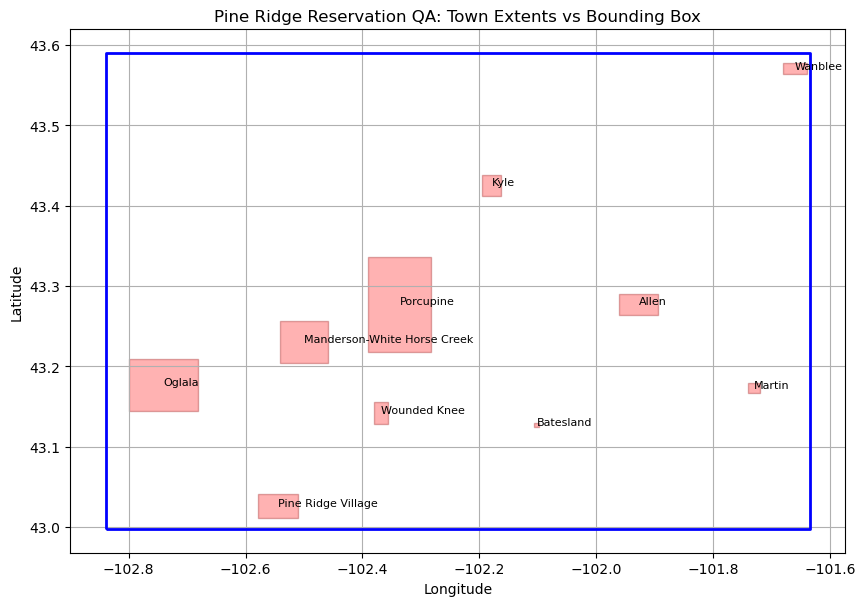

In [14]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 10))

# Reservation bounding box
reservation_gdf.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Reservation Bounding Box"
)

# Town extents
town_gdf.plot(
    ax=ax,
    facecolor="red",
    alpha=0.3,
    edgecolor="darkred"
)

# Labels (centroid-based labeling)
for x, y, label in zip(
    centroids.x,
    centroids.y,
    town_gdf["name"]
):
    ax.text(x, y, label, fontsize=8)

ax.set_title("Pine Ridge Reservation QA: Town Extents vs Bounding Box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.grid(True)
plt.show()

In [15]:
# QA checks
inside = town_gdf.within(reservation_gdf.geometry.iloc[0])

list(zip(town_gdf["name"], inside))

[('Martin', True),
 ('Batesland', True),
 ('Allen', True),
 ('Kyle', True),
 ('Manderson-White Horse Creek', True),
 ('Oglala', True),
 ('Pine Ridge Village', True),
 ('Porcupine', True),
 ('Wounded Knee', True),
 ('Wanblee', True)]

In [16]:
# Summary table
town_gdf.assign(within_reservation=inside)

,name,geometry,within_reservation
0,Martin,"POLYGON ((-101.72073 43.16733, -101.72073 43.1...",True
1,Batesland,"POLYGON ((-102.09815 43.12384, -102.09815 43.1...",True
2,Allen,"POLYGON ((-101.89514 43.26417, -101.89514 43.2...",True
3,Kyle,"POLYGON ((-102.16319 43.41174, -102.16319 43.4...",True
4,Manderson-White Horse Creek,"POLYGON ((-102.45839 43.20382, -102.45839 43.2...",True
5,Oglala,"POLYGON ((-102.68039 43.14452, -102.68039 43.2...",True
6,Pine Ridge Village,"POLYGON ((-102.51087 43.01166, -102.51087 43.0...",True
7,Porcupine,"POLYGON ((-102.28341 43.21776, -102.28341 43.3...",True
8,Wounded Knee,"POLYGON ((-102.35558 43.12863, -102.35558 43.1...",True
9,Wanblee,"POLYGON ((-101.64016 43.56322, -101.64016 43.5...",True


## Notes
This is a bounding box approximation, not the legal reservation boundary.
The actual Pine Ridge Reservation shape is highly irregular and spans multiple counties in South Dakota and Nebraska .
If you want a publication-quality map, the next step would be:
downloading BIA or Census TIGER/Line tribal boundary shapefiles
or using USGS, Tribal, or U.S. Census AIANNH boundary layers